# Embarrassingly Parallel MCMC via Consensus Monte Carlo

This example demonstrates how to scale Bayesian inference to large datasets using **embarrassingly parallel MCMC** methods. We show how to split a dataset into shards, run independent MCMC on each shard, and merge the subposteriors using two algorithms implemented in NumPyro:

- **Consensus Monte Carlo** (Scott et al., 2013)
- **Parametric Monte Carlo** (Neiswanger et al., 2014)

**References:**

1. Scott, S. L., Blocker, A. W., Bonassi, F. V., Chipman, H. A., George, E. I., & McCulloch, R. E. (2016). *Bayes and big data: The consensus Monte Carlo algorithm.* International Journal of Management Science and Engineering Management, 11(2), 78-88.
2. Neiswanger, W., Wang, C., & Xing, E. (2014). *Asymptotically exact, embarrassingly parallel MCMC.* Proceedings of the Thirtieth Conference on Uncertainty in Artificial Intelligence (UAI).

## Motivation: Why Embarrassingly Parallel MCMC?

Standard MCMC methods like NUTS (the No-U-Turn Sampler) evaluate the full log-likelihood at every leapfrog step. For a dataset of size $N$, this means each gradient evaluation costs $O(N)$, making posterior inference slow when $N$ is large (e.g., millions of observations).

There are several strategies to deal with this:

1. **Stochastic Variational Inference (SVI):** Optimizes a parametric approximation to the posterior using mini-batches. Very fast, but the approximate posterior may be misspecified (e.g., a mean-field Gaussian cannot capture multimodality or complex correlations).

2. **Data subsampling MCMC (e.g., HMCECS):** Uses mini-batches within a single MCMC chain, with control variates to correct the bias. Requires good reference parameters and is not trivially parallelizable across data.

3. **Embarrassingly parallel MCMC:** Splits the data across machines or cores, runs completely independent MCMC chains on each shard, and merges the results in a single post-processing step. There is **no communication between chains during sampling**, making this approach trivially parallelizable and easy to implement on distributed systems.

This tutorial focuses on the third approach.

## How Consensus Monte Carlo Works

### Setup

We want to draw samples from the posterior distribution:

$$p(\theta \mid D) \propto p(\theta) \prod_{i=1}^{N} p(y_i \mid x_i, \theta)$$

where $p(\theta)$ is the prior, $D = \{(x_i, y_i)\}_{i=1}^{N}$ is the full dataset, and $\theta$ are the model parameters.

### Step 1: Partition the data

Split the dataset $D$ into $K$ disjoint shards $D_1, D_2, \ldots, D_K$.

### Step 2: Define subposteriors

For each shard $k$, define a **subposterior**:

$$p_k(\theta \mid D_k) \propto p(\theta)^{1/K} \cdot \prod_{i \in D_k}
p(y_i \mid x_i, \theta)$$

The key insight is that the product of all $K$ subposteriors recovers the full posterior:

$$\prod_{k=1}^{K} p_k(\theta \mid D_k) \propto p(\theta) \cdot \prod_{i=1}^{N}
p(y_i \mid x_i, \theta) = p(\theta \mid D)$$

Each shard uses $p(\theta)^{1/K}$ (the prior raised to the power $1/K$) so that the prior is not over-counted when the subposteriors are combined. In practice, this is implemented by scaling the log-prior by $1/K$ using `numpyro.handlers.scale`.

### Step 3: Sample independently

Run MCMC (e.g., NUTS) on each shard independently. This is "embarrassingly parallel" since there is no inter-chain communication during sampling. Each chain produces samples $\{\theta_k^{(s)}\}_{s=1}^{S}$ from its subposterior $p_k(\theta \mid D_k)$.

### Step 4: Merge the subposteriors

Combine the $K$ sets of subposterior samples into a single set of samples approximating the full posterior. NumPyro provides two merging strategies:

#### Consensus MC (Scott et al., 2013)

Computes a **weighted average** of samples across shards. For each draw $s$, the merged sample is:

$$\theta^{*(s)} = \sum_{k=1}^{K} W_k \, \theta_k^{(s)}$$

where the weights $W_k$ are based on each shard's inverse covariance(precision matrix):

$$W_k = \left(\sum_{j=1}^{K} \Sigma_j^{-1}\right)^{-1} \Sigma_k^{-1}$$

and $\Sigma_k$ is the sample covariance of shard $k$'s subposterior.

With `diagonal=True`, the weights are computed per-parameter using inverse variances (cheaper, ignores cross-parameter correlations). With `diagonal=False`, full covariance matrices are used (captures correlations but is more expensive and can be numerically unstable in high dimensions).

This method preserves non-Gaussian features of the subposteriors to some extent, since it operates directly on the samples rather than fitting a parametric distribution.

#### Parametric MC (Neiswanger et al., 2014)

Fits a **Gaussian** to each subposterior by estimating its mean $\mu_k$ and covariance $\Sigma_k$, then analytically combines the Gaussians. The merged posterior is itself Gaussian with:

$$
\Sigma^{-1} = \sum_{k=1}^{K} \Sigma_k^{-1}, \qquad
\mu = \Sigma \sum_{k=1}^{K} \Sigma_k^{-1} \mu_k
$$

Fresh samples are then drawn from $\text{MultivariateNormal}(\mu, \Sigma)$. This is principled when the posterior is approximately Gaussian (which is often reasonable for large $N$ by the Bernstein-von Mises theorem), but will lose information about non-Gaussian features such as skewness or multimodality.

## When to Use Which Approach

| Method | Best for | Limitations |
|---|---|---|
| **NUTS** | Gold standard; data fits in memory; runtime acceptable | Cost per step $\propto N$; slow for very large $N$ |
| **SVI** | Fast approximate inference; very large data; deep models | Approximate posterior; may miss multimodality |
| **HMCECS** | Large data; want exact MCMC with subsampling | Needs reference params (e.g. from SVI); single chain |
| **Consensus MC** | Data too large for one machine; multiple GPUs available | Quality depends on Gaussian assumption; each shard needs enough data |
| **Parametric MC** | Same as consensus; want clean Gaussian approximation | Explicitly Gaussian; loses non-Gaussian features |

**Rules of thumb:**

- If your data fits in memory and NUTS runs in reasonable time, use NUTS.
- If you need speed and an approximate posterior is acceptable, use SVI.
- If data is too large for NUTS but the posterior is likely near-Gaussian
  (e.g., many observations per parameter, generalized linear models),
  consensus MC or parametric MC are good choices.
- Consensus MC works best when each shard has enough data that its
  subposterior is well-identified and approximately Gaussian (i.e., in
  the large-sample regime where the central limit theorem applies).

## Example: Bayesian Non-Linear Regression with RBF Basis Functions

We illustrate the method on a **non-linear regression** problem using radial basis function (RBF) features.

### RBF Basis Expansion

Given a scalar input $x$, we construct $K$ radial basis features:

$$
\phi_k(x) = \exp\!\left(-\frac{(x - c_k)^2}{2 \ell^2}\right),
\qquad k = 1, \ldots, K
$$

where $c_1, \ldots, c_K$ are evenly spaced centers and $\ell$ is a fixed lengthscale. The model is then:

$$
y_i = \sum_{k=1}^{K} w_k \, \phi_k(x_i) + \varepsilon_i, \qquad \varepsilon_i \sim \text{Normal}(0, \sigma^2)
$$

The parameters are the RBF weights $w_1, \ldots, w_K$ and the noise standard deviation $\sigma$.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from jax import random
import jax.numpy as jnp

import numpyro
import numpyro.distributions as dist
from numpyro.handlers import scale
from numpyro.infer import MCMC, NUTS
from numpyro.infer.hmc_util import consensus, parametric_draws
from numpyro.infer.util import Predictive

plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.key(seed=42)

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

### True Function and Data Generation

We generate synthetic data from a known non-linear function corrupted by Gaussian noise.


In [2]:
def true_function(x):
    """The true underlying function: a sum of sinusoids."""
    return jnp.sin(2 * x) + 0.3 * jnp.cos(5 * x)


def make_rbf_basis(x, num_centers=15, x_range=(-3.0, 3.0)):
    """Construct RBF basis matrix.

    Places `num_centers` Gaussian basis functions evenly across `x_range`
    with a lengthscale chosen so that neighboring bases overlap smoothly.
    """
    centers = jnp.linspace(x_range[0], x_range[1], num_centers)
    # Lengthscale ~ spacing between centers (ensures smooth overlap)
    lengthscale = (x_range[1] - x_range[0]) / (num_centers - 1)
    # Basis matrix: (N, K)
    return jnp.exp(-0.5 * ((x[:, None] - centers[None, :]) / lengthscale) ** 2)


def generate_data(rng_key, num_obs=10_000, x_range=(-3.0, 3.0)):
    k1, k2 = random.split(rng_key)
    x = random.uniform(k1, (num_obs,), minval=x_range[0], maxval=x_range[1])
    noise_std = 0.3
    y = true_function(x) + noise_std * random.normal(k2, (num_obs,))
    return x, y

In [3]:
# Generate synthetic data and construct the RBF basis matrix.

NUM_CENTERS = 15
X_RANGE = (-3.0, 3.0)
NUM_OBS = 1_000

rng_key, data_key = random.split(rng_key)
x, y = generate_data(data_key, num_obs=NUM_OBS, x_range=X_RANGE)
basis = make_rbf_basis(x, num_centers=NUM_CENTERS, x_range=X_RANGE)
print(f"Dataset: {NUM_OBS} observations, {NUM_CENTERS} RBF basis functions")
print(
    f"Model parameters: {NUM_CENTERS} weights + 1 noise std = {NUM_CENTERS + 1} total"
)

Dataset: 1000 observations, 15 RBF basis functions
Model parameters: 15 weights + 1 noise std = 16 total


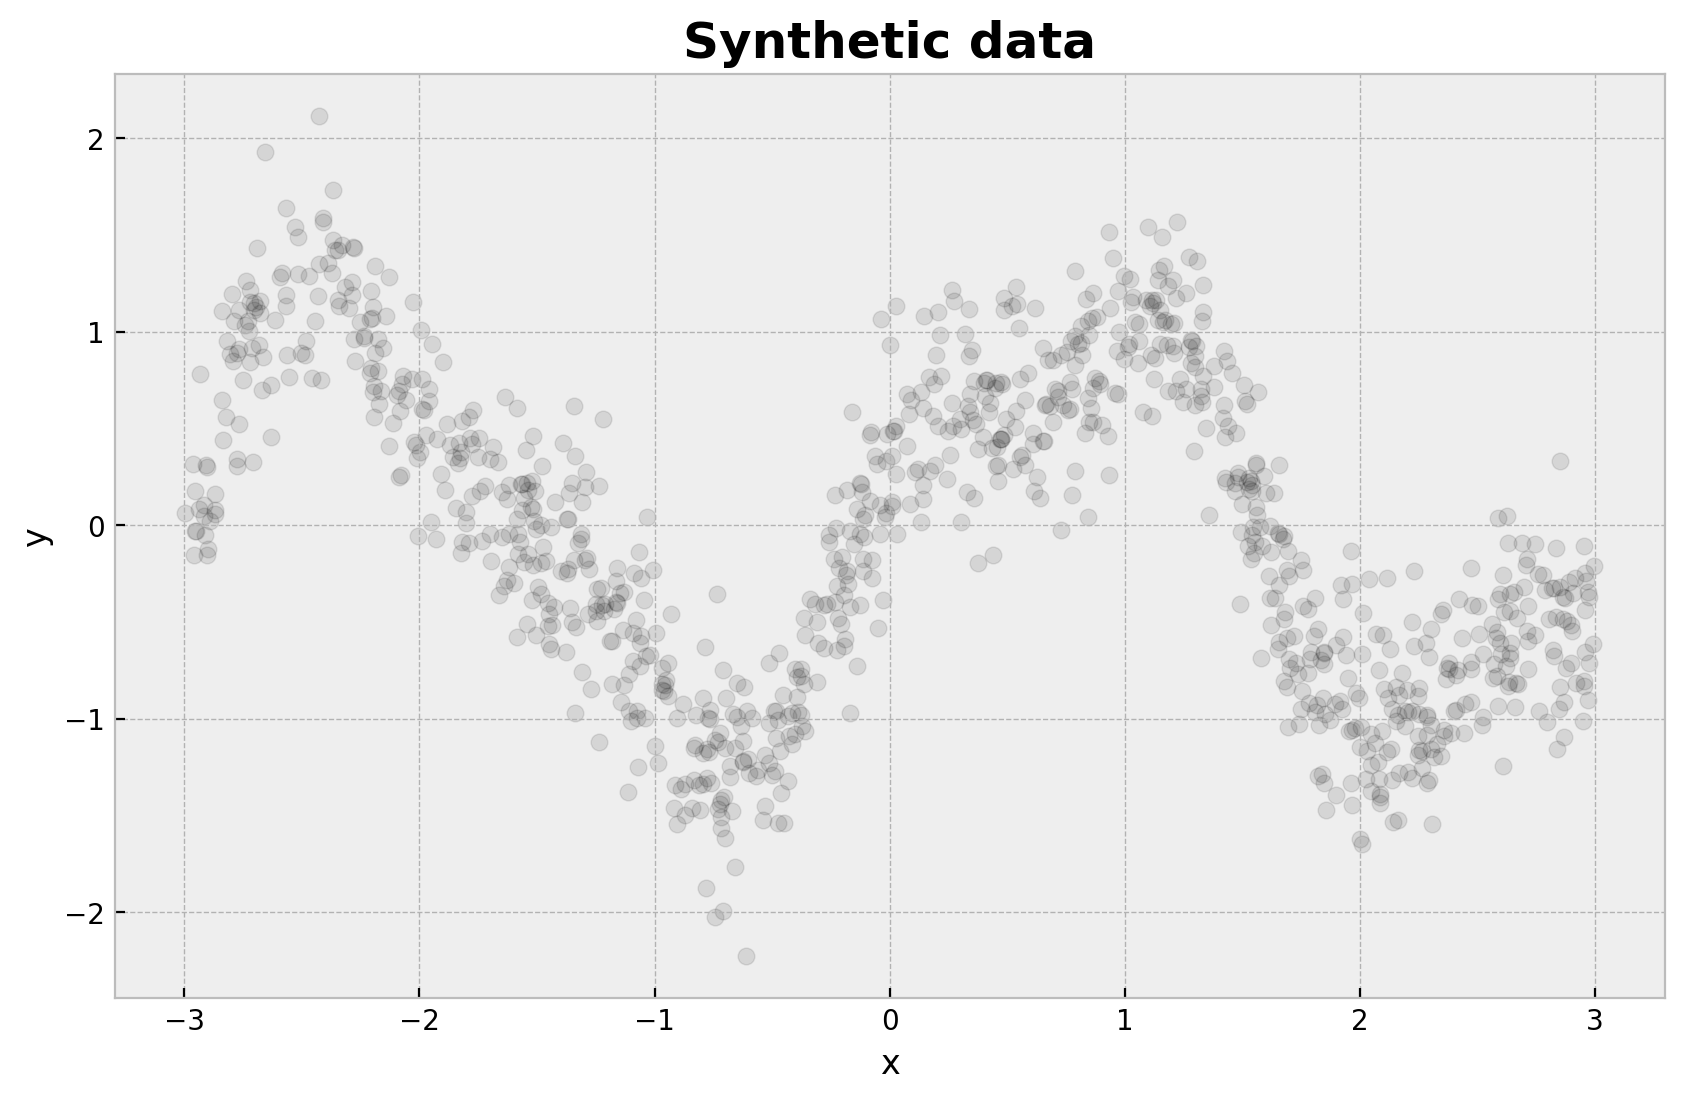

In [4]:
fig, ax = plt.subplots()
ax.scatter(x, y, c="black", alpha=0.1)
ax.set(xlabel="x", ylabel="y")
ax.set_title("Synthetic data", fontsize=18, fontweight="bold");

### Model Definition

The model places a Normal prior on the RBF weights and a HalfNormal prior on the observation noise. The `prior_scale` argument scales the log-prior by $1/K$ for each of the $K$ shards, implemented via `numpyro.handlers.scale`.

Note that only the **prior** is scaled, not the likelihood. Each shard sees the full likelihood on its own data partition.


In [5]:
def model(basis, y=None, prior_scale=1.0):
    num_basis = basis.shape[1]
    with scale(scale=prior_scale):
        weights = numpyro.sample(
            "weights", dist.Normal(jnp.zeros(num_basis), 2.0 * jnp.ones(num_basis))
        )
        sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    mu = basis @ weights
    numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)

### MCMC Helper

A utility function that runs NUTS on a given dataset shard with the specified prior scaling.

In [6]:
def run_mcmc(
    rng_key,
    basis,
    y,
    prior_scale=1.0,
    num_warmup=500,
    num_samples=1000,
    num_chains=1,
):
    kernel = NUTS(model)
    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        progress_bar=True,
    )
    mcmc.run(rng_key, basis, y, prior_scale)
    return mcmc

### Full-Data MCMC (Baseline)

We run NUTS on the **entire** dataset with the full prior (`prior_scale=1.0`). This is the gold-standard baseline.

In [7]:
def run_full_mcmc(rng_key, basis, y, num_warmup, num_samples, num_chains):
    return run_mcmc(
        rng_key,
        basis,
        y,
        prior_scale=1.0,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
    )

In [8]:
%%time

# Run full-data NUTS (baseline).

num_warmup = 1_000
num_samples = 2_000
num_chains = 1

rng_key, mcmc_key = random.split(rng_key)
full_mcmc = run_full_mcmc(
    mcmc_key,
    basis,
    y,
    num_warmup=num_warmup,
    num_samples=num_samples,
    num_chains=num_chains,
)

full_posterior_predictive = Predictive(model, full_mcmc.get_samples())
rng_key, predictive_key = random.split(rng_key)

idata_full_mcmc = az.from_numpyro(
    posterior=full_mcmc,
    posterior_predictive=full_posterior_predictive(predictive_key, basis),
    coords={"weights_idx": jnp.arange(NUM_CENTERS)},
    dims={"weights": ["weights_idx"]},
)

sample: 100%|██████████| 3000/3000 [00:03<00:00, 859.08it/s, 127 steps of size 3.35e-02. acc. prob=0.91]


CPU times: user 9.29 s, sys: 717 ms, total: 10 s
Wall time: 5.18 s


### Sharded MCMC

We split the data into `num_shards` disjoint partitions and run independent NUTS on each shard. Each shard uses `prior_scale = 1/K` so that the prior contributions sum to the full prior when combined. Note that we shuffle the data before splitting to ensure each shard has a representative mix of input locations.

In [9]:
def run_sharded_mcmc(
    rng_key, basis, y, num_shards, num_warmup, num_samples, num_chains
):
    N = basis.shape[0]
    shard_size = N // num_shards
    subposteriors = []

    prior_scale = 1.0 / num_shards

    # Shuffle data before splitting into shards
    rng_key, shuffle_key = random.split(rng_key)
    perm = random.permutation(shuffle_key, N)
    basis_shuffled = basis[perm]
    y_shuffled = y[perm]

    for k in tqdm(range(num_shards)):
        rng_key, sub_key = random.split(rng_key)
        start = k * shard_size
        end = start + shard_size if k < num_shards - 1 else N
        basis_k = basis_shuffled[start:end]
        y_k = y_shuffled[start:end]

        samples_k = run_mcmc(
            sub_key,
            basis_k,
            y_k,
            prior_scale=prior_scale,
            num_warmup=num_warmup,
            num_samples=num_samples,
            num_chains=num_chains,
        ).get_samples()

        subposteriors.append(samples_k)

    return subposteriors

In [10]:
%%time

# Run sharded NUTS (embarrassingly parallel).

num_shards = 4

rng_key, shard_key = random.split(rng_key)
subposteriors = run_sharded_mcmc(
    shard_key,
    basis,
    y,
    num_shards=num_shards,
    num_warmup=num_warmup,
    num_samples=num_samples,
    num_chains=num_chains,
)

  0%|          | 0/4 [00:00<?, ?it/s]

sample: 100%|██████████| 3000/3000 [00:02<00:00, 1205.29it/s, 127 steps of size 4.02e-02. acc. prob=0.88]

CPU times: user 21.4 s, sys: 2.01 s, total: 23.4 s
Wall time: 10.3 s


### Merging Subposteriors

We apply both merging strategies with both `diagonal=True` and `diagonal=False`:

- `consensus(diagonal=True)`: per-parameter inverse-variance weighting
- `consensus(diagonal=False)`: full inverse-covariance weighting
- `parametric_draws(diagonal=True)`: Gaussian merge with diagonal covariance
- `parametric_draws(diagonal=False)`: Gaussian merge with full covariance

In [11]:
def merge_subposteriors(subposteriors, num_draws, rng_key):
    k1, k2, k3, k4 = random.split(rng_key, 4)
    results = {
        "Consensus (diagonal)": consensus(
            subposteriors, num_draws=num_draws, diagonal=True, rng_key=k1
        ),
        "Consensus (full cov)": consensus(
            subposteriors, num_draws=num_draws, diagonal=False, rng_key=k2
        ),
        "Parametric (diagonal)": parametric_draws(
            subposteriors, num_draws=num_draws, diagonal=True, rng_key=k3
        ),
        "Parametric (full cov)": parametric_draws(
            subposteriors, num_draws=num_draws, diagonal=False, rng_key=k4
        ),
    }
    return results

In [12]:
# Merge the subposteriors.

rng_key, merge_key = random.split(rng_key)
merged = merge_subposteriors(subposteriors, num_draws=num_samples, rng_key=merge_key)

We store the results as an inferencedata object for each method.

In [13]:
idatas = {}

idatas["Full NUTS"] = idata_full_mcmc

for method, samples in merged.items():
    idata = az.from_dict(
        {k: v[jnp.newaxis, :] for k, v in merged["Consensus (diagonal)"].items()},
        coords={"weights_idx": jnp.arange(NUM_CENTERS)},
        dims={"weights": ["weights_idx"]},
    )

    rng_key, predictive_key = random.split(rng_key)
    pred = Predictive(model, samples)
    posterior_predictive = az.from_numpyro(
        posterior_predictive=pred(predictive_key, basis),
        coords={"obs_idx": jnp.arange(NUM_OBS)},
        dims={"obs": ["obs_idx"]},
    )
    idata.extend(posterior_predictive)
    idatas[method] = idata

## Plotting

We now analize some plots to understand the results.

### Posterior

We plot the posterior distributions of the RBF weights and the noise standard deviation.

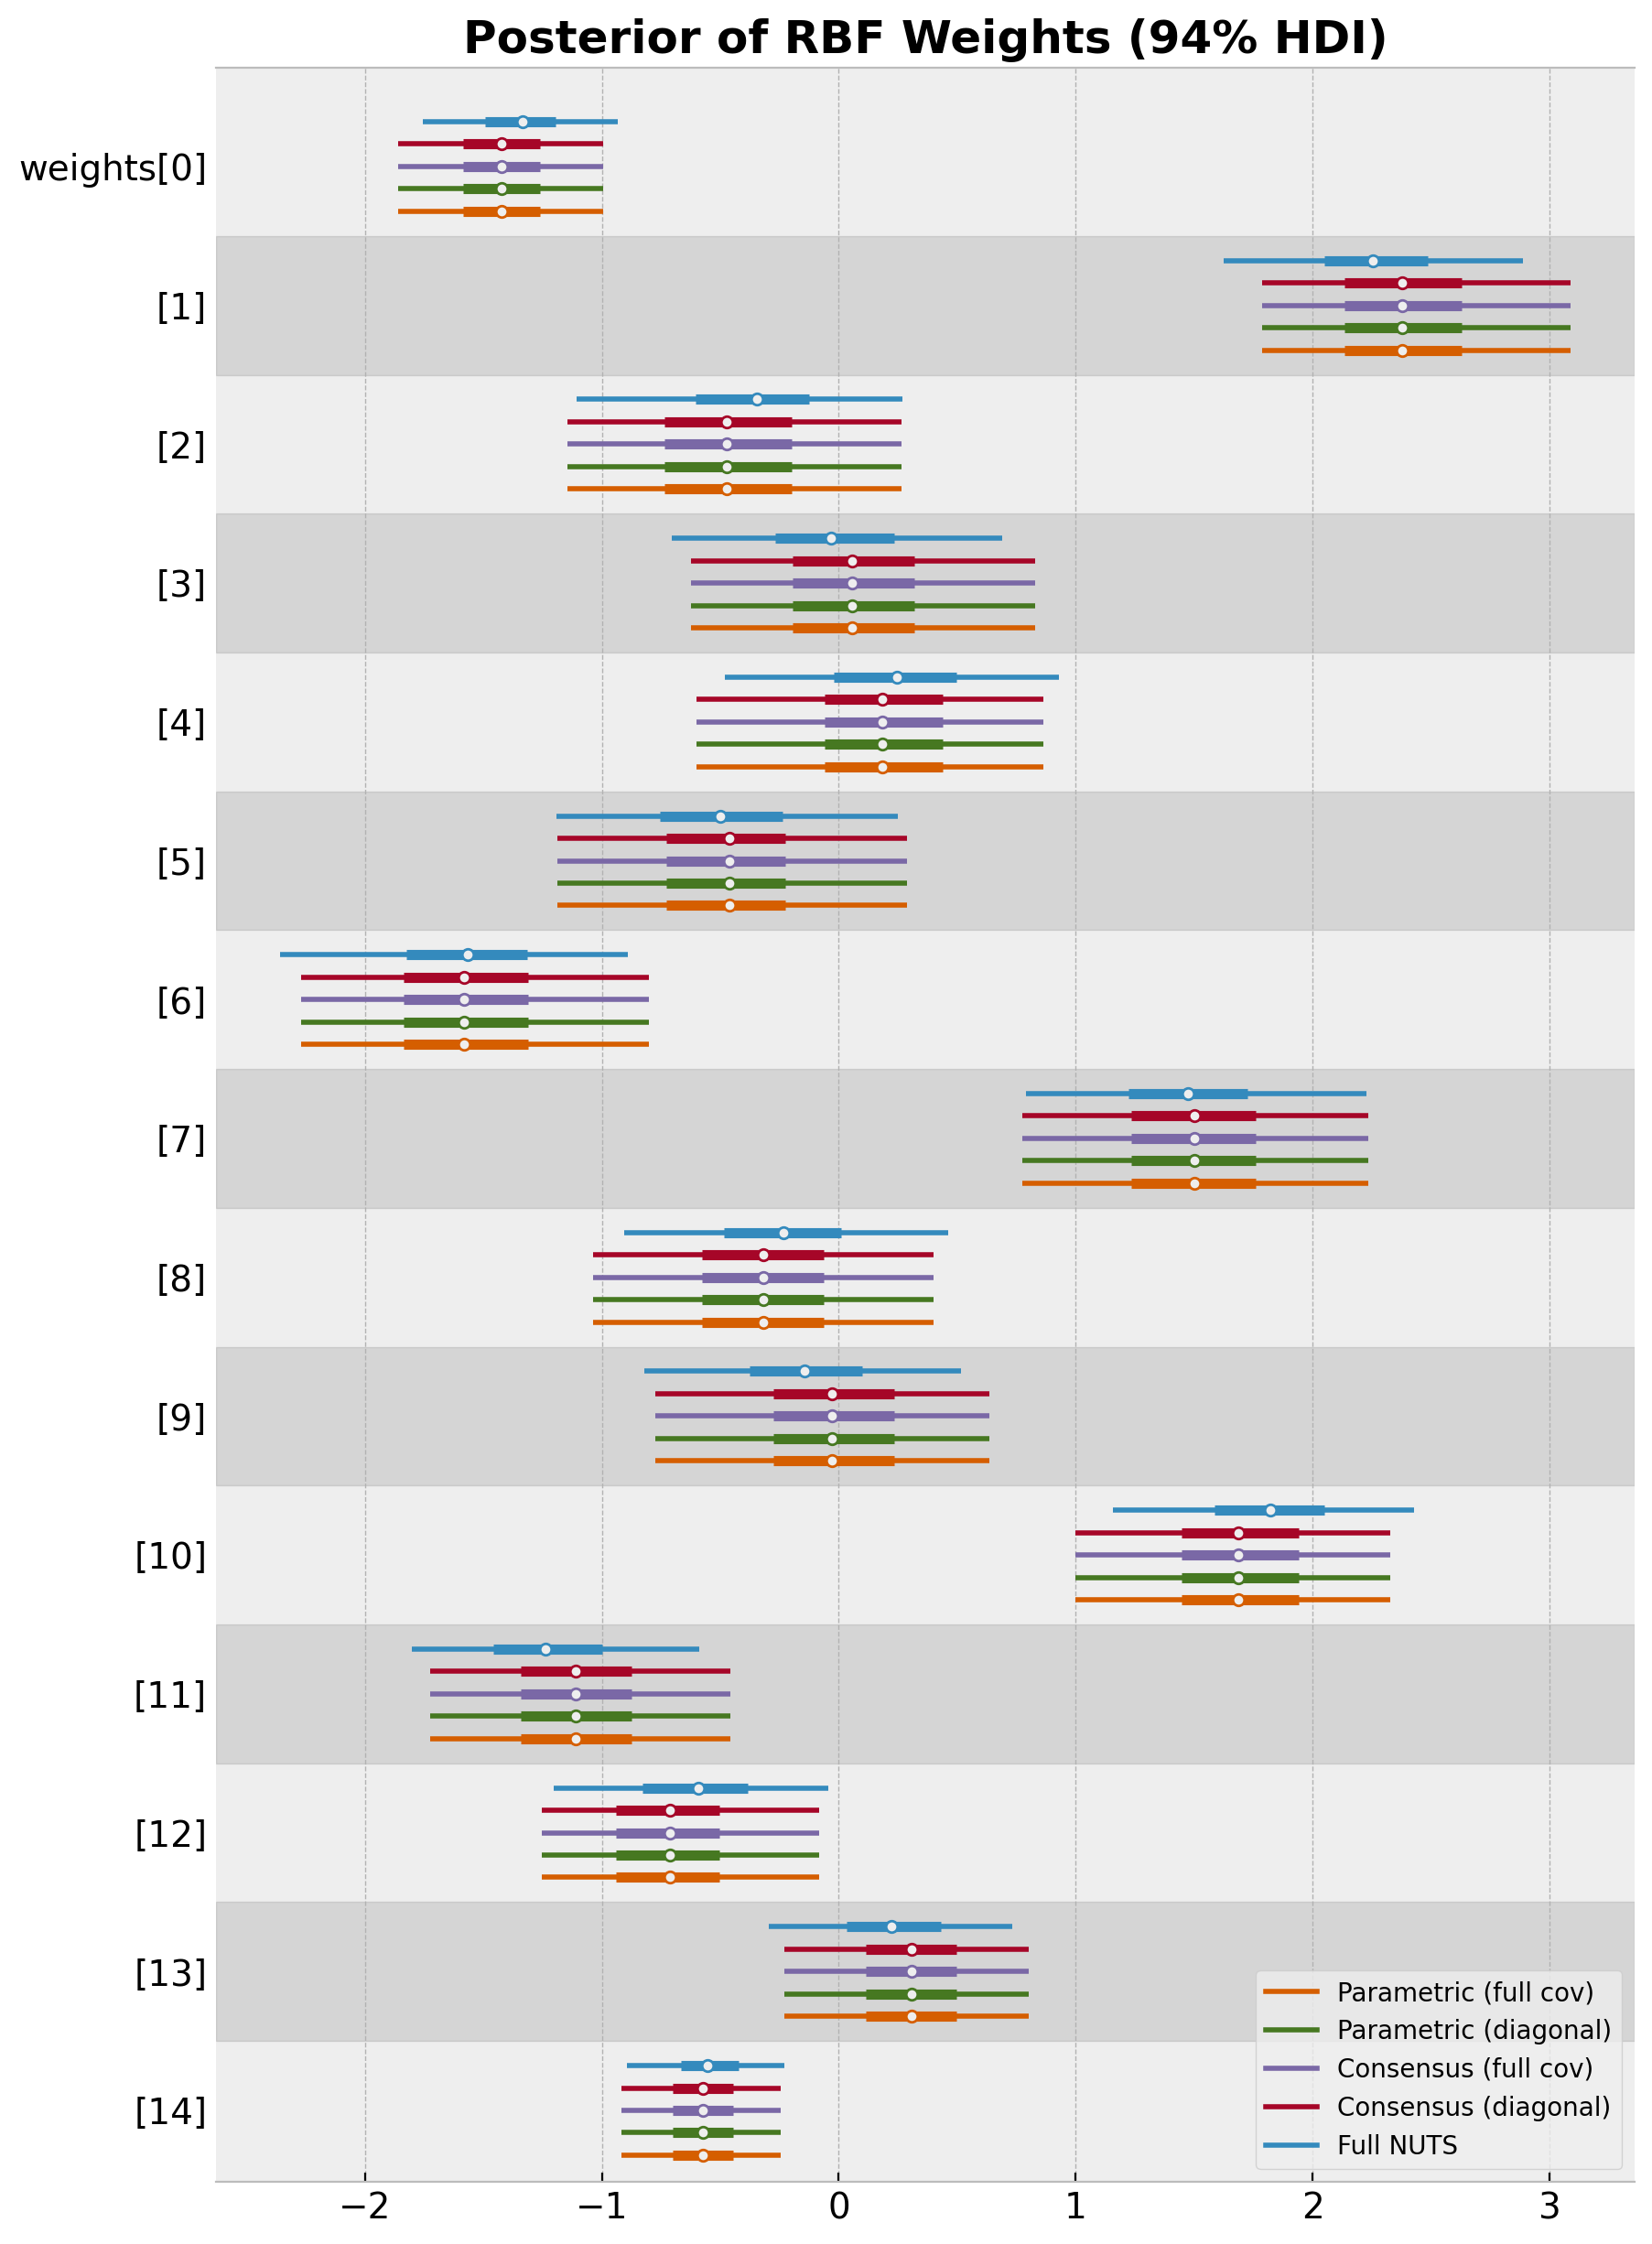

In [14]:
ax, *_ = az.plot_forest(
    [p["posterior"]["weights"] for p in idatas.values()],
    model_names=idatas.keys(),
    combined=True,
    figsize=(10, 15),
)

legend = ax.get_legend()
legend.set_loc("lower right")
ax.set_title("Posterior of RBF Weights (94% HDI)", fontsize=18, fontweight="bold");

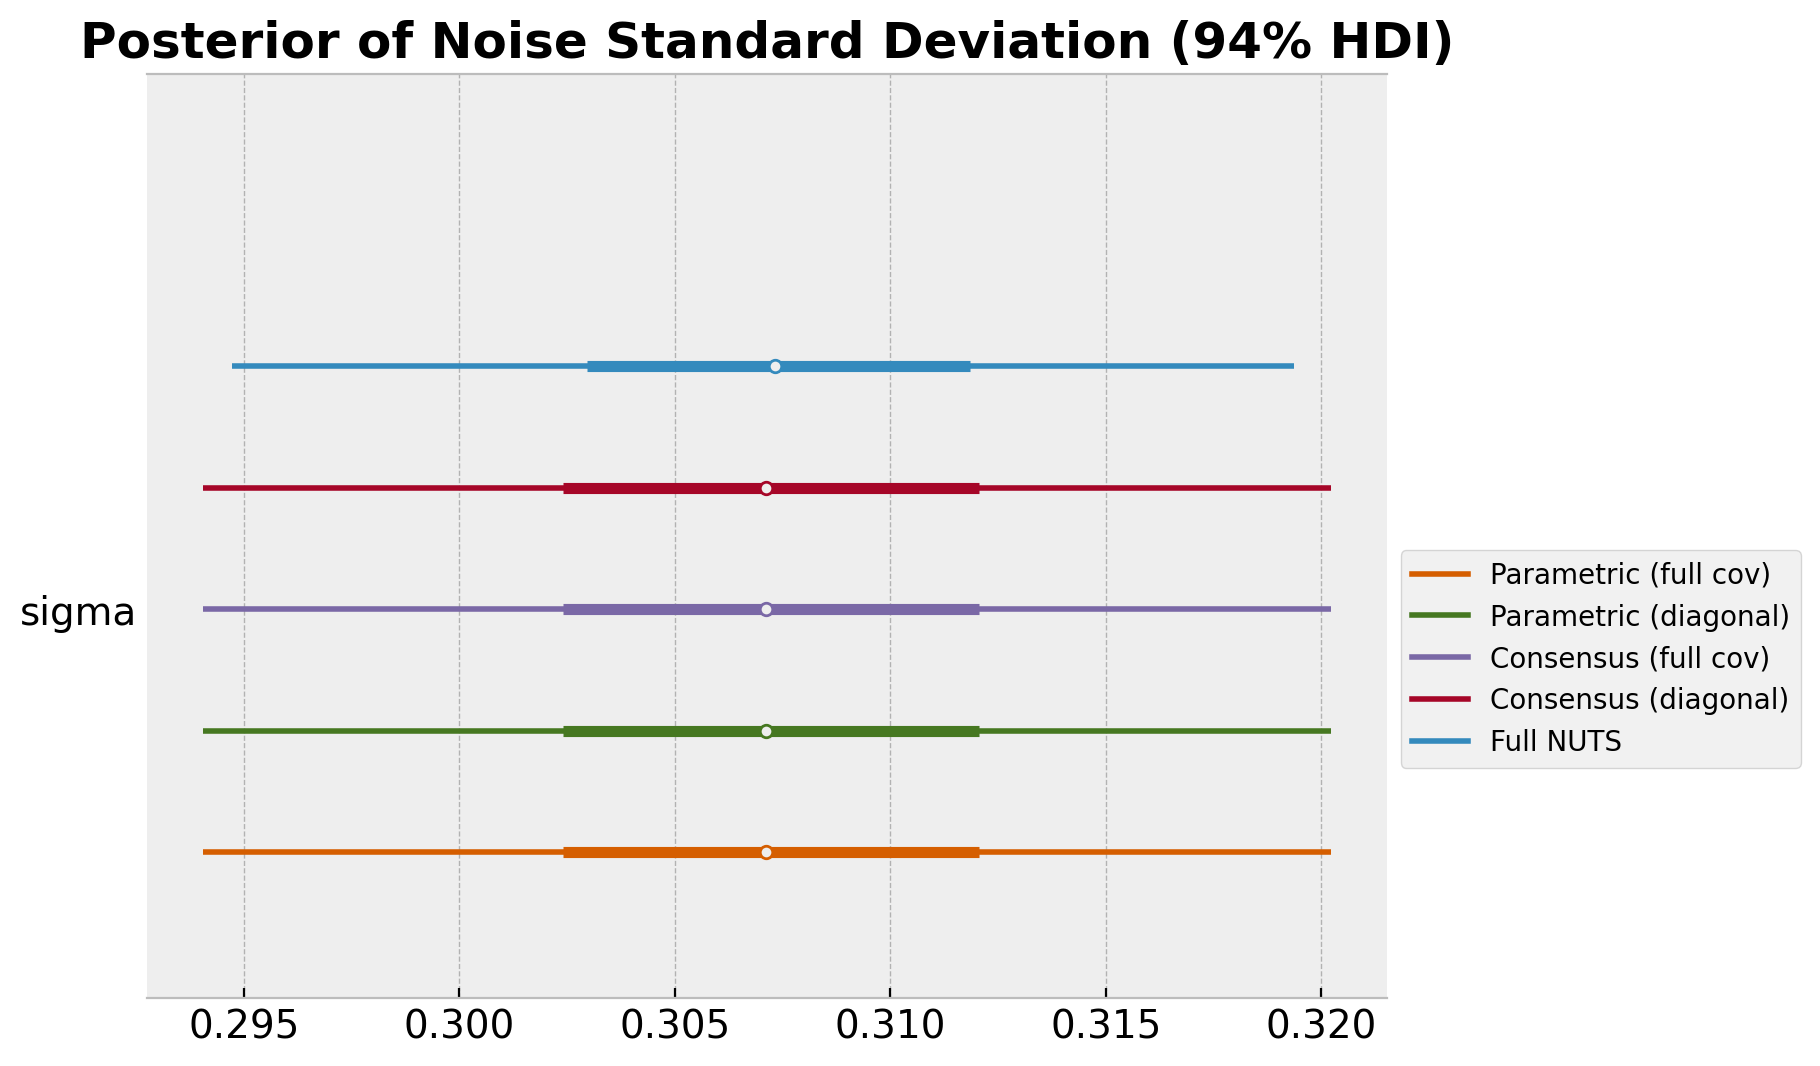

In [15]:
ax, *_ = az.plot_forest(
    [p["posterior"]["sigma"] for p in idatas.values()],
    model_names=idatas.keys(),
    combined=True,
    figsize=(8, 6),
)

legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 0.5))
ax.set_title(
    "Posterior of Noise Standard Deviation (94% HDI)", fontsize=18, fontweight="bold"
);

### Posterior Predictive

For each method, we compute the posterior predictive mean and a $94\%$ and $50\%$ credible intervals.

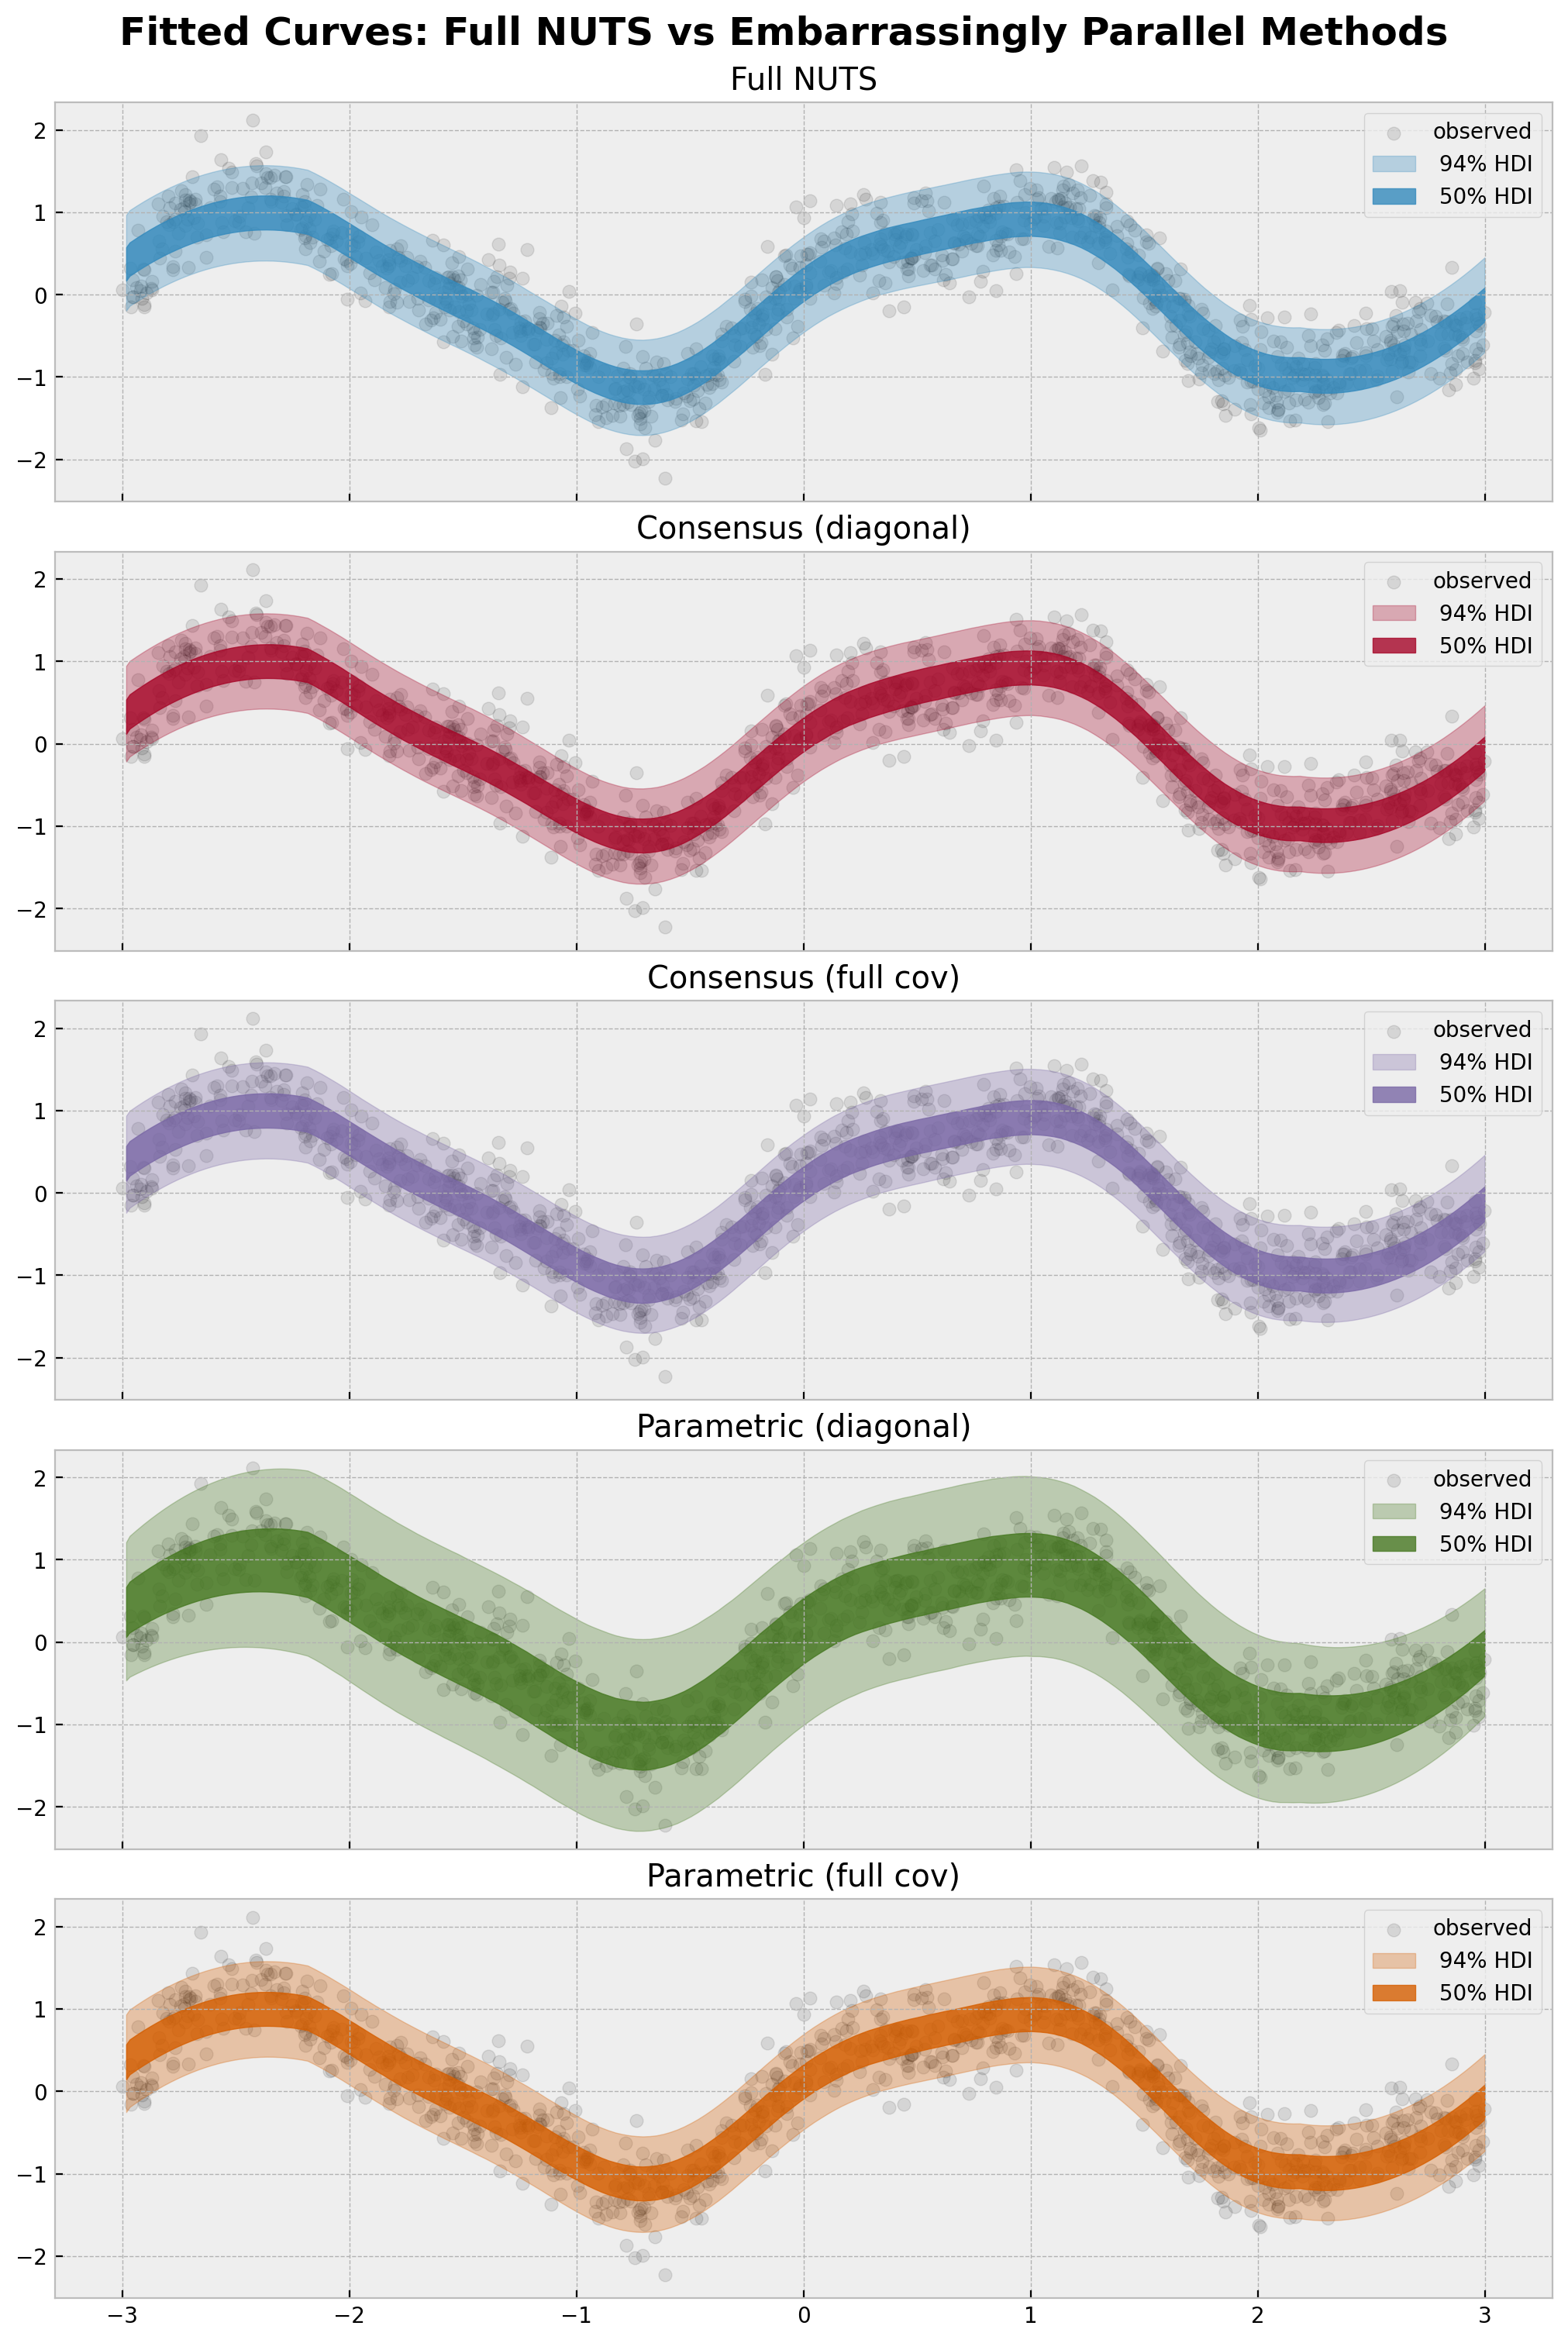

In [16]:
def plot_posterior_predictive(x, y, idatas):

    fig, ax = plt.subplots(
        nrows=len(idatas),
        ncols=1,
        figsize=(10, 15),
        sharex=True,
        sharey=True,
        layout="constrained",
    )

    for j, (method, idata) in enumerate(idatas.items(), start=0):
        ax[j].scatter(x, y, c="black", alpha=0.1, label="observed")
        for i, hdi in enumerate([0.94, 0.5]):
            az.plot_hdi(
                x,
                idata["posterior_predictive"]["obs"],
                hdi_prob=hdi,
                color=f"C{j}",
                fill_kwargs={"alpha": 0.3 + 0.5 * i, "label": f"{hdi: .0%} HDI"},
                ax=ax[j],
            )
        ax[j].legend(loc="upper right")
        ax[j].set_title(method)

    fig.suptitle(
        "Fitted Curves: Full NUTS vs Embarrassingly Parallel Methods",
        fontsize=18,
        fontweight="bold",
    )


plot_posterior_predictive(x, y, idatas)

### 2D Posterior Correlations

We plot the joint posterior of two neighboring RBF weights. Since neighboring basis functions overlap spatially, their weights are negatively correlated.

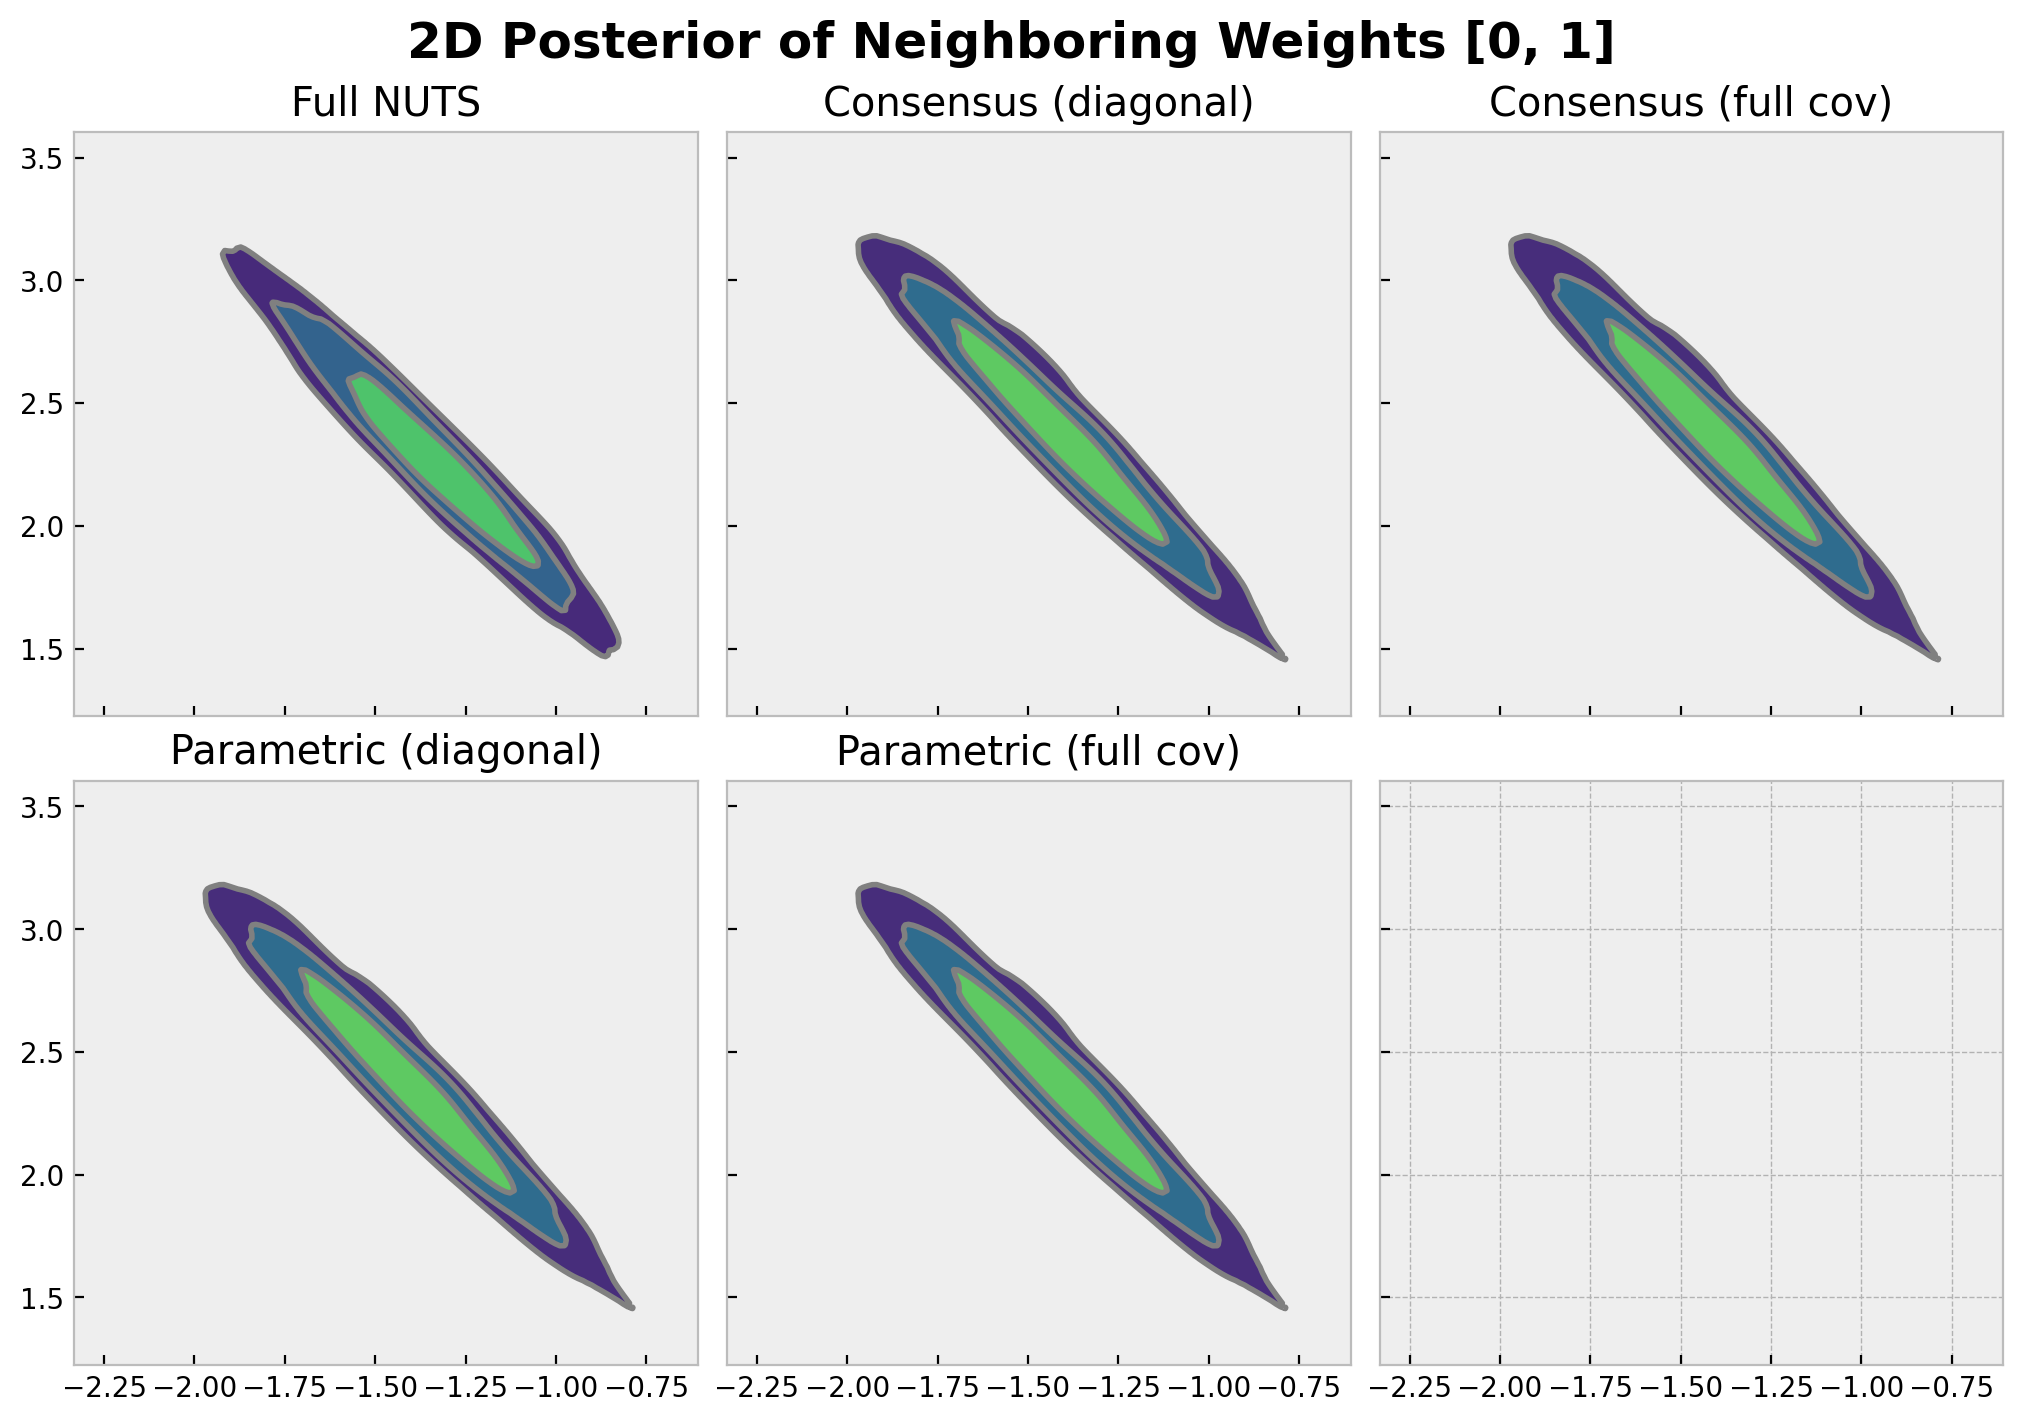

In [17]:
def plot_2d_comparison(idatas, idx0=6, idx1=7):
    fig, ax = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(10, 7),
        sharex=True,
        sharey=True,
        layout="constrained",
    )

    ax = ax.flatten()

    for i, (method, idata) in enumerate(idatas.items()):
        az.plot_kde(
            idata.posterior["weights"].sel(chain=0, weights_idx=idx0),
            idata.posterior["weights"].sel(chain=0, weights_idx=idx1),
            ax=ax[i],
        )
        ax[i].set_title(method)

    fig.suptitle(
        f"2D Posterior of Neighboring Weights [{idx0}, {idx1}]",
        fontsize=18,
        fontweight="bold",
    )


plot_2d_comparison(idatas, idx0=0, idx1=1)